# J & Z Gesture Recognition — MediaPipe + LSTM

| Cell | What it does | Run when |
|------|-------------|----------|
| 1 | Install packages (numpy pinned last) | Once only |
| 2 | Setup and config | Every time you open notebook |
| 3 | Generate collect_jz.py script | Once — then run in terminal |
| 4 | Check data quality + delete bad sequences | After collecting |
| 5 | Train LSTM model | After collecting |
| 6 | Evaluate model — accuracy + confusion matrix | After training |
| 7 | Test J and Z live (inline) | After training |
| 8 | Combined A-Z detection (YOLOv8 + LSTM) | Final demo |

---
# CELL 1 — Install Packages
### Run ONCE. After it finishes → RESTART KERNEL → then run Cell 2 onwards.

In [1]:
import subprocess, sys

# Step 1 — uninstall any broken mediapipe
subprocess.check_call([sys.executable, '-m', 'pip', 'uninstall', 'mediapipe', '-y', '-q'])

# Step 2 — install packages IN THIS ORDER (numpy must be last)
packages = [
    'mediapipe==0.10.9',
    'protobuf==3.20.3',
    'ultralytics',
    'seaborn',
    'scikit-learn',
    'numpy==1.24.3',   # MUST be last — mediapipe upgrades numpy to 2.x which breaks TF 2.10
]
for pkg in packages:
    print(f'Installing {pkg}...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q',
                           '--force-reinstall' if 'numpy' in pkg else ''])

print('\n✅ Done!')
print('⚠️  RESTART KERNEL NOW: Kernel → Restart Kernel')
print('   Then run Cell 2 onwards — do NOT re-run Cell 1')

Installing mediapipe==0.10.9...
Installing protobuf==3.20.3...
Installing ultralytics...
Installing seaborn...
Installing scikit-learn...
Installing numpy==1.24.3...

✅ Done!
⚠️  RESTART KERNEL NOW: Kernel → Restart Kernel
   Then run Cell 2 onwards — do NOT re-run Cell 1


---
# CELL 2 — Setup and Config
### Run EVERY TIME you open this notebook

In [2]:
import os, numpy as np, cv2, mediapipe as mp, tensorflow as tf
from collections import deque
import matplotlib
matplotlib.use('Agg')  # prevents GUI backend error on Windows
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
from PIL import Image as PILImage
import io, time

# ── Verify versions ───────────────────────────────
print(f'numpy      : {np.__version__}')   # should be 1.24.3
print(f'mediapipe  : {mp.__version__}')   # should be 0.10.9
print(f'tensorflow : {tf.__version__}')   # should be 2.10.x
print(f'GPU        : {tf.config.list_physical_devices("GPU")}')

# ── YOUR PROJECT PATH — change if needed ──────────
PROJECT_PATH    = r'E:\Study\Projects\REAL-TIME OBJECT DETECTION FOR ASSISTING COMMUNICATION IN NON-VERBAL INDIVIDUALS'

DATA_PATH       = os.path.join(PROJECT_PATH, 'JZ_Data')
YOLO_MODEL_PATH = os.path.join(PROJECT_PATH, 'sign_lang_best.pt')
LSTM_MODEL_PATH = os.path.join(PROJECT_PATH, 'jz_lstm_model.keras')

# ── Config ────────────────────────────────────────
GESTURES        = [ 'J' , 'Z' ] #, 'Z'
SEQUENCES       = 40       # sequences per gesture
SEQUENCE_LENGTH = 60       # frames per sequence (~1 second at 30fps)
NUM_LANDMARKS   = 63       # 21 hand landmarks × 3 (x, y, z)
CONF_THRESHOLD  = 0.5      # detection confidence threshold
YOLO_CLASSES    = list('ABCDEFGHIKLMNOPQRSTUVWXY')

# ── Create data folders ───────────────────────────
for g in GESTURES:
    for s in range(SEQUENCES):
        os.makedirs(os.path.join(DATA_PATH, g, str(s)), exist_ok=True)

# ── MediaPipe setup ──────────────────────────────
mp_hands   = mp.solutions.hands
mp_drawing = mp.solutions.drawing_utils
mp_styles  = mp.solutions.drawing_styles

def get_hands():
    """Lower confidence (0.5) helps detect hand during difficult J/Z angles."""
    return mp_hands.Hands(
        static_image_mode=False, max_num_hands=1,
        min_detection_confidence=0.5,
        min_tracking_confidence=0.5)

def extract_landmarks(results):
    """Returns 63 values (21 landmarks × x,y,z). All zeros if no hand detected."""
    if results.multi_hand_landmarks:
        return np.array([[lm.x, lm.y, lm.z]
            for lm in results.multi_hand_landmarks[0].landmark]).flatten()
    return np.zeros(NUM_LANDMARKS)

def show_frame(frame, title=''):
    """Display a cv2 frame inline in Jupyter notebook."""
    clear_output(wait=True)
    plt.figure(figsize=(10, 6))
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    if title: plt.title(title, fontsize=13)
    buf = io.BytesIO()
    plt.savefig(buf, format='png', bbox_inches='tight')
    buf.seek(0)
    display(PILImage.open(buf))
    plt.close()

print('\n✅ Setup complete!')
print(f'   Data path  : {DATA_PATH}')
print(f'   YOLO model : {os.path.exists(YOLO_MODEL_PATH)}')
print(f'   LSTM model : {os.path.exists(LSTM_MODEL_PATH)} (created after Cell 5)')

e:\Study\Projects\REAL-TIME OBJECT DETECTION FOR ASSISTING COMMUNICATION IN NON-VERBAL INDIVIDUALS\ObjEnv\lib\site-packages\google\api_core\_python_version_support.py:246: FutureWarning: You are using a non-supported Python version (3.9.13). Google will not post any further updates to google.api_core supporting this Python version. Please upgrade to the latest Python version, or at least Python 3.10, and then update google.api_core.
  warnings.warn(message, FutureWarning)
e:\Study\Projects\REAL-TIME OBJECT DETECTION FOR ASSISTING COMMUNICATION IN NON-VERBAL INDIVIDUALS\ObjEnv\lib\site-packages\google\auth\__init__.py:54: FutureWarning: You are using a Python version 3.9 past its end of life. Google will update google-auth with critical bug fixes on a best-effort basis, but not with any other fixes or features. Please upgrade your Python version, and then update google-auth.
  warnings.warn(eol_message.format("3.9"), FutureWarning)
e:\Study\Projects\REAL-TIME OBJECT DETECTION FOR ASSIST

numpy      : 1.24.3
mediapipe  : 0.10.9
tensorflow : 2.10.1
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

✅ Setup complete!
   Data path  : E:\Study\Projects\REAL-TIME OBJECT DETECTION FOR ASSISTING COMMUNICATION IN NON-VERBAL INDIVIDUALS\JZ_Data
   YOLO model : True
   LSTM model : True (created after Cell 5)


---
# CELL 3 — Generate Data Collection Script
### Run this cell, then open a SEPARATE terminal and run:
### `python collect_jz.py`
### J: point index finger up → draw J shape down → hook left (keep palm facing camera)
### Z: draw Z in air right→diagonal→right (keep palm facing camera throughout)

In [44]:
collection_script = f'''
import cv2, numpy as np, mediapipe as mp, os

DATA_PATH       = r"{DATA_PATH}"
GESTURES        = {GESTURES}
SEQUENCES       = {SEQUENCES}
SEQUENCE_LENGTH = {SEQUENCE_LENGTH}

mp_hands   = mp.solutions.hands
mp_drawing = mp.solutions.drawing_utils
hands      = mp_hands.Hands(
    max_num_hands=1,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5)

def extract_landmarks(results):
    if results.multi_hand_landmarks:
        return np.array([[lm.x, lm.y, lm.z]
            for lm in results.multi_hand_landmarks[0].landmark]).flatten()
    return np.zeros(63)

cap = cv2.VideoCapture(0)
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)
cap.set(cv2.CAP_PROP_FPS, 30)
if not cap.isOpened():
    cap = cv2.VideoCapture(1)
    if not cap.isOpened():
        print("Camera not found!"); exit()

print("Camera ready! Press Q to stop early")
stopped = False

for gesture in GESTURES:
    if stopped: break
    print(f"\\n--- Gesture: {{gesture}} ---")
    for seq in range(SEQUENCES):
        if stopped: break
        seq_path = os.path.join(DATA_PATH, gesture, str(seq))
        existing = len([f for f in os.listdir(seq_path) if f.endswith(".npy")])
        if existing == SEQUENCE_LENGTH:
            print(f"  Seq {{seq+1}}: already complete, skipping")
            continue
        print(f"  Seq {{seq+1}}/{SEQUENCES} — GET READY")
        for countdown in range(3, 0, -1):
            ret, frame = cap.read()
            frame = cv2.flip(frame, 1)
            cv2.rectangle(frame, (0,0), (frame.shape[1], frame.shape[0]), (0,0,0), -1)
            cv2.putText(frame, str(countdown),
                (frame.shape[1]//2-60, frame.shape[0]//2+50),
                cv2.FONT_HERSHEY_SIMPLEX, 6, (0,255,0), 8)
            cv2.putText(frame, f"Draw: {{gesture}}",
                (50, 80), cv2.FONT_HERSHEY_SIMPLEX, 2.5, (255,255,0), 4)
            cv2.putText(frame, "KEEP PALM FACING CAMERA",
                (50, 160), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0,200,255), 2)
            cv2.imshow("Collecting J Z — Q to stop", frame)
            if cv2.waitKey(1000) & 0xFF == ord("q"): stopped=True; break
        if stopped: break
        for frame_num in range(SEQUENCE_LENGTH):
            ret, frame = cap.read()
            frame = cv2.flip(frame, 1)
            rgb  = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            res  = hands.process(rgb)
            if res.multi_hand_landmarks:
                mp_drawing.draw_landmarks(
                    frame, res.multi_hand_landmarks[0], mp_hands.HAND_CONNECTIONS)
            lm = extract_landmarks(res)
            np.save(os.path.join(seq_path, str(frame_num)), lm)
            prog = int(frame_num / SEQUENCE_LENGTH * frame.shape[1])
            cv2.rectangle(frame, (0, frame.shape[0]-20),
                (prog, frame.shape[0]), (0,255,0), -1)
            cv2.putText(frame, f"RECORDING {{gesture}}",
                (50, 70), cv2.FONT_HERSHEY_SIMPLEX, 2, (0,0,255), 4)
            cv2.putText(frame, f"Frame {{frame_num+1}}/{SEQUENCE_LENGTH}",
                (50, 140), cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,0), 2)
            status = "Hand OK" if res.multi_hand_landmarks else "NO HAND — keep palm visible!"
            color  = (0,255,0) if res.multi_hand_landmarks else (0,0,255)
            cv2.putText(frame, status, (50, 200),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)
            cv2.imshow("Collecting J Z — Q to stop", frame)
            if cv2.waitKey(33) & 0xFF == ord("q"): stopped=True; break 
        print(f"  Seq {{seq+1}} done")

cap.release()
cv2.destroyAllWindows()
print("\\n=== DONE ===")
for g in GESTURES:
    d    = os.path.join(DATA_PATH, g)
    seqs = [s for s in os.listdir(d) if os.path.isdir(os.path.join(d,s))]
    done = sum(1 for s in seqs
               if len(os.listdir(os.path.join(d,s))) == SEQUENCE_LENGTH)
    print(f"  {{g}}: {{done}}/{SEQUENCES} sequences complete")
'''

# if cv2.waitKey(33) & 0xFF == ord("q"): stopped=True; break  -- 33 - 30fps (1000ms ÷ 30)

script_path = os.path.join(PROJECT_PATH, 'collect_jz.py')
with open(script_path, 'w', encoding='utf-8') as f:
    f.write(collection_script)

print('✅ collect_jz.py written!')
print()
print('Open a NEW terminal (not this Jupyter terminal) and run:')
print(f'   cd "{PROJECT_PATH}"')
print( '   ObjEnv\\Scripts\\activate')
print( '   python collect_jz.py')
print()
print('Tips for better detection:')
print('  - Keep palm FACING the camera throughout the motion')
print('  - Draw slowly — 1.5 to 2 seconds per gesture')
print('  - Stay 40-60cm from camera — hand fills ~40% of frame')
print('  - Watch for "NO HAND" warning — stop and redo that sequence')

✅ collect_jz.py written!

Open a NEW terminal (not this Jupyter terminal) and run:
   cd "E:\Study\Projects\REAL-TIME OBJECT DETECTION FOR ASSISTING COMMUNICATION IN NON-VERBAL INDIVIDUALS"
   ObjEnv\Scripts\activate
   python collect_jz.py

Tips for better detection:
  - Keep palm FACING the camera throughout the motion
  - Draw slowly — 1.5 to 2 seconds per gesture
  - Stay 40-60cm from camera — hand fills ~40% of frame
  - Watch for "NO HAND" warning — stop and redo that sequence


---
# CELL 4 — Check Data Quality + Delete Bad Sequences
### Run after collecting to see how many zero-landmark frames per sequence
### Then use the delete cell below to clear bad sequences and recollect

Data Quality Check

J [OK]:
  Perfect  (0% zeros)    : 17/40
  Usable   (1-10% zeros) : 23/40
  Bad      (>10% zeros)  : 0/40
  Avg zero frames        : 1.0%


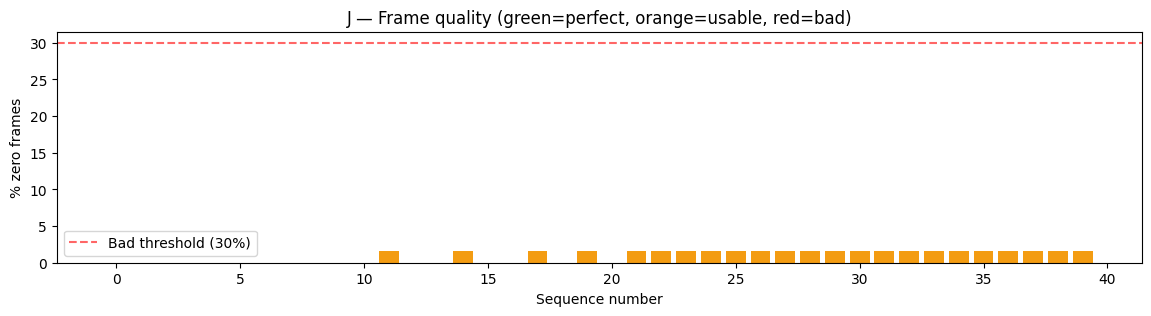


Z [OK]:
  Perfect  (0% zeros)    : 4/40
  Usable   (1-10% zeros) : 36/40
  Bad      (>10% zeros)  : 0/40
  Avg zero frames        : 1.5%


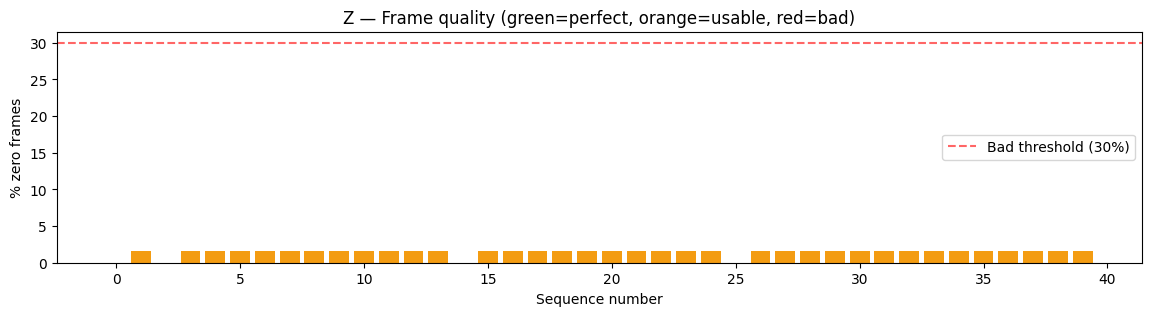


All sequences look good! Proceed to Cell 5.


In [3]:
print('Data Quality Check')
print('='*60)

all_ok = True
bad_sequences = {g: [] for g in GESTURES}

for gesture in GESTURES:
    gpath = os.path.join(DATA_PATH, gesture)
    if not os.path.exists(gpath):
        print(f'{gesture}: folder missing — run Cell 3 first')
        all_ok = False
        continue

    seqs = sorted([d for d in os.listdir(gpath)
                   if os.path.isdir(os.path.join(gpath,d))], key=int)

    zero_pcts = []
    for s in seqs:
        zeros = sum(
            1 for f in range(SEQUENCE_LENGTH)
            if os.path.exists(os.path.join(gpath, s, f'{f}.npy'))
            and np.all(np.load(os.path.join(gpath, s, f'{f}.npy')) == 0)
        )
        pct = zeros / SEQUENCE_LENGTH * 100
        zero_pcts.append(pct)
        if pct > 10:
            bad_sequences[gesture].append(int(s))

    perfect  = sum(1 for p in zero_pcts if p == 0)
    usable   = sum(1 for p in zero_pcts if 0 < p <= 10)
    bad      = sum(1 for p in zero_pcts if p > 10)
    avg_zero = np.mean(zero_pcts) if zero_pcts else 0

    status = 'OK' if bad == 0 else 'NEEDS WORK'
    print(f'\n{gesture} [{status}]:')
    print(f'  Perfect  (0% zeros)    : {perfect}/{len(seqs)}')
    print(f'  Usable   (1-10% zeros) : {usable}/{len(seqs)}')
    print(f'  Bad      (>10% zeros)  : {bad}/{len(seqs)}')
    print(f'  Avg zero frames        : {avg_zero:.1f}%')
    if bad_sequences[gesture]:
        print(f'  Bad sequence numbers   : {bad_sequences[gesture]}')
        all_ok = False

    # Bar chart — one bar per sequence
    if zero_pcts:
        colors = ['#2ecc71' if p==0 else '#f39c12' if p<=30 else '#e74c3c'
                  for p in zero_pcts]
        fig, ax = plt.subplots(figsize=(14, 3))
        ax.bar(range(len(zero_pcts)), zero_pcts, color=colors)
        ax.axhline(30, color='red',    linestyle='--', alpha=0.6, label='Bad threshold (30%)')
        ax.set_xlabel('Sequence number')
        ax.set_ylabel('% zero frames')
        ax.set_title(f'{gesture} — Frame quality (green=perfect, orange=usable, red=bad)')
        ax.legend()
        buf = io.BytesIO()
        plt.savefig(buf, format='png', bbox_inches='tight')
        buf.seek(0)
        display(PILImage.open(buf))
        plt.close()

print('\n' + '='*60)
if all_ok:
    print('All sequences look good! Proceed to Cell 5.')
else:
    print('Bad sequences found.')
    print('Run the DELETE cell below, then run collect_jz.py again.')
    for g, bseqs in bad_sequences.items():
        if bseqs:
            print(f'  {g}: delete sequences {bseqs}')

In [46]:
# ── Delete bad sequences ───────────────────────────
# After running the quality check above, copy the bad sequence
# numbers here, then run this cell, then run collect_jz.py again.
# collect_jz.py will skip complete sequences and only re-record cleared ones.

import shutil

# ⬇️ PASTE YOUR BAD SEQUENCE NUMBERS HERE
CLEAR = {
    'J': [],   # e.g. [1, 7, 8, 14, 15, 16, 18, 29, 30, 36, 38]
    'Z': [2 , 37],   # e.g. [0, 5, 18]
}

for gesture, seqs_to_clear in CLEAR.items():
    for s in seqs_to_clear:
        seq_path = os.path.join(DATA_PATH, gesture, str(s))
        if os.path.exists(seq_path):
            for f in os.listdir(seq_path):
                os.remove(os.path.join(seq_path, f))
            print(f'  Cleared {gesture} sequence {s}')
        else:
            print(f'  {gesture} sequence {s} not found')

if not any(CLEAR.values()):
    print('Nothing to clear — add sequence numbers to CLEAR dict above')
else:
    print('\nDone! Now run collect_jz.py in terminal to re-record cleared sequences.')

  Cleared Z sequence 2
  Cleared Z sequence 37

Done! Now run collect_jz.py in terminal to re-record cleared sequences.


### ⚠️⚠️ Delete Old Data First (Ful dataset is deleted) ⚠️⚠️

In [19]:
import shutil, os

for gesture in ['J', 'Z']:
    path = os.path.join(DATA_PATH, gesture)
    shutil.rmtree(path)
    for s in range(SEQUENCES):
        os.makedirs(os.path.join(path, str(s)), exist_ok=True)

print('Cleared! Ready to recollect with 60 frames.')

Cleared! Ready to recollect with 60 frames.


---
# CELL 5 — Train LSTM Model
### Run after Cell 4 shows data is good
### Input: sequences of (30 frames × 63 values) — Output: J or Z
### Model saved as jz_lstm_model.keras

In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

# ── Load sequences ────────────────────────────────
print('Loading sequences...')
X, y = [], []
for idx, gesture in enumerate(GESTURES):
    gpath = os.path.join(DATA_PATH, gesture)
    seqs  = sorted([d for d in os.listdir(gpath)
                    if os.path.isdir(os.path.join(gpath,d))], key=int)
    ok = 0
    for s in seqs:
        frames, complete = [], True
        for f in range(SEQUENCE_LENGTH):
            p = os.path.join(gpath, s, f'{f}.npy')
            if not os.path.exists(p): complete=False; break
            frames.append(np.load(p))
        if complete:
            X.append(frames); y.append(idx); ok += 1
    print(f'  {gesture}: {ok} sequences loaded')

X = np.array(X)   # shape: (N, 30, 63)
y = to_categorical(y, len(GESTURES))
print(f'\nX shape: {X.shape}  |  y shape: {y.shape}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y.argmax(axis=1))
print(f'Train: {len(X_train)}  |  Test: {len(X_test)}')

# ── Build model ───────────────────────────────────
model = Sequential([
    LSTM(128, return_sequences=True,
         input_shape=(SEQUENCE_LENGTH, NUM_LANDMARKS)),  # (60, 63)
    BatchNormalization(), Dropout(0.2),   # reduced dropout — you have clean data

    LSTM(64, return_sequences=True),
    BatchNormalization(), Dropout(0.2),

    LSTM(32, return_sequences=False),
    BatchNormalization(), Dropout(0.1),   # less dropout on final LSTM

    Dense(64, activation='relu'),         # bigger dense layer
    Dropout(0.2),
    Dense(32, activation='relu'),         # added extra dense
    Dense(len(GESTURES), activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),  # lower LR — more precise
    loss='categorical_crossentropy',
    metrics=['accuracy'])
model.summary()

# ── Train ─────────────────────────────────────────
callbacks = [
    EarlyStopping(
        monitor   = 'val_accuracy',
        patience  = 40,            # more patience — 60 frames needs more epochs
        restore_best_weights = True,
        verbose   = 1),
    ReduceLROnPlateau(
        monitor   = 'val_loss',
        factor    = 0.3,           # more aggressive LR reduction
        patience  = 15,
        min_lr    = 1e-7,
        verbose   = 1),
    ModelCheckpoint(
        LSTM_MODEL_PATH,
        monitor        = 'val_accuracy',
        save_best_only = True,
        verbose        = 1)
]

print('\nTraining LSTM...')
history = model.fit(
    X_train, y_train,
    epochs          = 300,   # more epochs — early stopping will cut it short
    batch_size      = 16,    # larger batch — you have 80 sequences now
    validation_data = (X_test, y_test),
    callbacks       = callbacks,
    verbose         = 1)

print(f'\nModel saved: {LSTM_MODEL_PATH}')

Loading sequences...
  J: 40 sequences loaded
  Z: 40 sequences loaded

X shape: (80, 60, 63)  |  y shape: (80, 2)
Train: 64  |  Test: 16
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 60, 128)           98304     
                                                                 
 batch_normalization (BatchN  (None, 60, 128)          512       
 ormalization)                                                   
                                                                 
 dropout (Dropout)           (None, 60, 128)           0         
                                                                 
 lstm_1 (LSTM)               (None, 60, 64)            49408     
                                                                 
 batch_normalization_1 (Batc  (None, 60, 64)           256       
 hNormalization)                                  

---
# CELL 6 — Evaluate Model
### Run after training to see accuracy + confusion matrix + training curves


RESULTS
  Accuracy : 100.0%
  Loss     : 0.6483
              precision    recall  f1-score   support

           J       1.00      1.00      1.00         8
           Z       1.00      1.00      1.00         8

    accuracy                           1.00        16
   macro avg       1.00      1.00      1.00        16
weighted avg       1.00      1.00      1.00        16



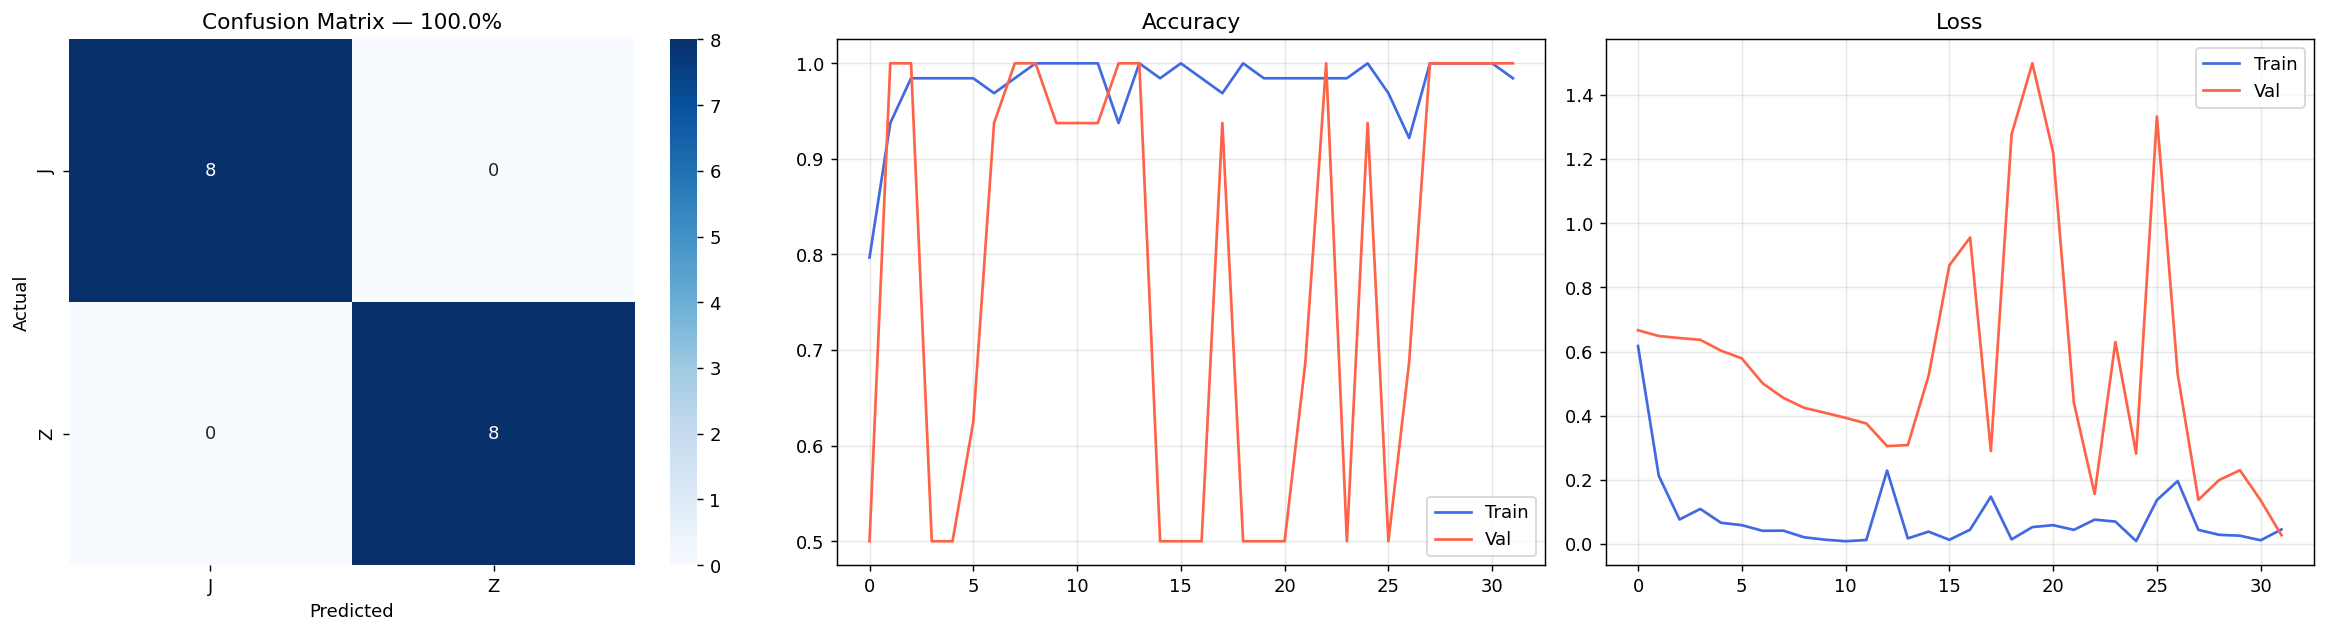

Excellent — ready for deployment!


In [49]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

loss, acc = model.evaluate(X_test, y_test, verbose=0)
y_pred    = model.predict(X_test, verbose=0)

print(f'\nRESULTS')
print('='*35)
print(f'  Accuracy : {acc*100:.1f}%')
print(f'  Loss     : {loss:.4f}')
print('='*35)
print(classification_report(y_test.argmax(1), y_pred.argmax(1),
                             target_names=GESTURES))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm = confusion_matrix(y_test.argmax(1), y_pred.argmax(1))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=GESTURES, yticklabels=GESTURES, ax=axes[0])
axes[0].set_title(f'Confusion Matrix — {acc*100:.1f}%')
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')

axes[1].plot(history.history['accuracy'],     label='Train', color='royalblue')
axes[1].plot(history.history['val_accuracy'], label='Val',   color='tomato')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(history.history['loss'],     label='Train', color='royalblue')
axes[2].plot(history.history['val_loss'], label='Val',   color='tomato')
axes[2].set_title('Loss'); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
buf = io.BytesIO()
plt.savefig(buf, format='png', bbox_inches='tight', dpi=130)
buf.seek(0)
display(PILImage.open(buf))
plt.close()

if acc >= 0.95:
    print('Excellent — ready for deployment!')
elif acc >= 0.80:
    print('Good — collect more sequences for better results')
else:
    print('Needs more data — collect more sequences and retrain')

---
# CELL 7 — Test J and Z Live (Inline)
### Tests only LSTM — press Stop (square) in Jupyter to quit
### Blue bar at bottom = sequence buffer filling up
### Detection triggers when buffer is full (after ~1 second)

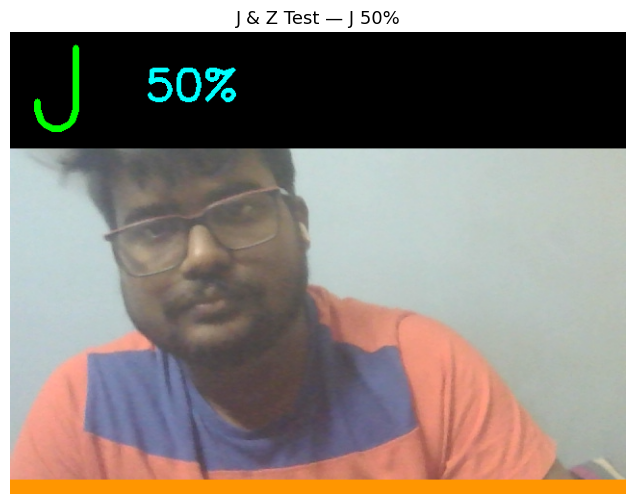

Stopped.


In [52]:
import gc
try: del lstm_test
except: pass
gc.collect()

lstm_test = tf.keras.models.load_model(LSTM_MODEL_PATH)
print(f'LSTM loaded: {LSTM_MODEL_PATH}')

hands_det   = get_hands()
sequence    = deque(maxlen=SEQUENCE_LENGTH)
frame_count = 0

cap = cv2.VideoCapture(0)
if not cap.isOpened():
    cap = cv2.VideoCapture(1)
print('Running — press Stop (square) to quit')

try:
    while True:
        ret, frame = cap.read()
        if not ret: break
        frame   = cv2.flip(frame, 1)
        rgb     = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = hands_det.process(rgb)

        if results.multi_hand_landmarks:
            mp_drawing.draw_landmarks(
                frame, results.multi_hand_landmarks[0],
                mp_hands.HAND_CONNECTIONS,
                mp_styles.get_default_hand_landmarks_style(),
                mp_styles.get_default_hand_connections_style())

        lm = extract_landmarks(results)
        sequence.append(lm)

        label, conf = '', 0
        if len(sequence) == SEQUENCE_LENGTH:
            pred  = lstm_test.predict(
                np.expand_dims(np.array(sequence), 0), verbose=0)[0]
            conf  = float(np.max(pred))
            if conf > CONF_THRESHOLD:
                label = GESTURES[np.argmax(pred)]

        h, w = frame.shape[:2]
        cv2.rectangle(frame, (0,0), (w,120), (0,0,0), -1)
        if label:
            cv2.putText(frame, label, (20,100),
                cv2.FONT_HERSHEY_SIMPLEX, 4, (0,255,0), 6)
            cv2.putText(frame, f'{conf:.0%}', (140,70),
                cv2.FONT_HERSHEY_SIMPLEX, 1.5, (255,255,0), 3)
        else:
            cv2.putText(frame, 'Draw J or Z...', (20,70),
                cv2.FONT_HERSHEY_SIMPLEX, 1.5, (150,150,150), 2)

        prog = int(len(sequence) / SEQUENCE_LENGTH * w)
        cv2.rectangle(frame, (0,h-15), (prog,h), (0,150,255), -1)

        frame_count += 1
        if frame_count % 8 == 0:
            show_frame(frame,
                f'J & Z Test — {label if label else "(none)"} '
                f'{f"{conf:.0%}" if conf > 0 else ""}')
except KeyboardInterrupt:
    pass
finally:
    cap.release()
    print('Stopped.')

---
# CELL 8 — Combined A-Z Detection
### YOLOv8 handles A-I and K-Y (static gestures)
### LSTM handles J and Z (motion gestures)
### Hold any letter ~2 seconds → auto-added to word
### Press Stop (square) to quit

In [10]:
import torch
torch.cuda.empty_cache()

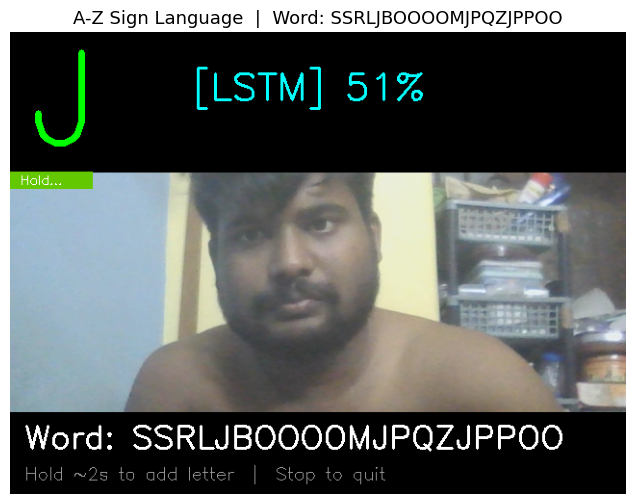

Exception ignored in: <function UniquePtr.__del__ at 0x0000025FF1209940>
Traceback (most recent call last):
  File "e:\Study\Projects\REAL-TIME OBJECT DETECTION FOR ASSISTING COMMUNICATION IN NON-VERBAL INDIVIDUALS\ObjEnv\lib\site-packages\tensorflow\python\framework\c_api_util.py", line 71, in __del__
    obj = self._obj
AttributeError: _obj



✅ Stopped.
   Letters detected : ['S', 'S', 'R', 'L', 'J', 'B', 'O', 'O', 'O', 'O', 'M', 'J', 'P', 'Q', 'Z', 'J', 'P', 'P', 'O', 'O']
   Final word       : SSRLJBOOOOMJPQZJPPOO


In [3]:
import gc, torch, time
import numpy as np
import cv2
import mediapipe as mp
import tensorflow as tf
from ultralytics import YOLO
from collections import deque
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
from PIL import Image as PILImage
import io

# ── Clear memory first ────────────────────────────
try: del yolo_model, lstm_model
except: pass
gc.collect()
torch.cuda.empty_cache()
tf.keras.backend.clear_session()

# ── Load YOLOv8 on GPU ────────────────────────────
print('Loading YOLOv8 on GPU...')
yolo_model = YOLO('AY_data/models/final_v4/weights/sign_lang_AY_v4.pt')

# ── Load LSTM on CPU (prevents VRAM conflict) ─────
print('Loading LSTM on CPU...')
with tf.device('/CPU:0'):
    lstm_model = tf.keras.models.load_model('./jz_lstm_model.keras')

print('✅ Both models ready!')
print('   YOLOv8 → GPU | LSTM → CPU')

# ── Config ────────────────────────────────────────
CONF_THRESHOLD = 0.5
GESTURES       = ['J', 'Z']
SEQUENCE_LENGTH= 60    # must match how you trained LSTM
NUM_LANDMARKS  = 63

# ── MediaPipe setup ──────────────────────────────
mp_hands   = mp.solutions.hands
mp_drawing = mp.solutions.drawing_utils
hands_det  = mp_hands.Hands(
    max_num_hands=1,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5)

def extract_landmarks(results):
    if results.multi_hand_landmarks:
        return np.array([[lm.x, lm.y, lm.z]
            for lm in results.multi_hand_landmarks[0].landmark]).flatten()
    return np.zeros(NUM_LANDMARKS)

def show_frame(frame, title=''):
    clear_output(wait=True)
    plt.figure(figsize=(10, 6))
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    if title: plt.title(title, fontsize=13)
    buf = io.BytesIO()
    plt.savefig(buf, format='png', bbox_inches='tight')
    buf.seek(0)
    display(PILImage.open(buf))
    plt.close()

# ── State ─────────────────────────────────────────
sequence      = deque(maxlen=SEQUENCE_LENGTH)
letter_history= []
current_letter= ''
last_letter   = ''
stable_count  = 0
STABLE_NEEDED = 30
last_add_time = 0
AUTO_ADD_DELAY= 1.5
frame_count   = 0

# ── Camera ────────────────────────────────────────
cap = cv2.VideoCapture(0)
cap.set(cv2.CAP_PROP_BUFFERSIZE, 1)
if not cap.isOpened():
    cap = cv2.VideoCapture(1)
    if not cap.isOpened():
        print('❌ Camera not found!')

print('\nRunning A-Z detection...')
print('Hold any letter ~2 seconds → auto-added')
print('Press Stop (■) to quit\n')

try:
    while True:
        ret, frame = cap.read()
        if not ret: break
        frame = cv2.flip(frame, 1)

        # ── YOLO on GPU ───────────────────────────
        yolo_res         = yolo_model(frame, conf=CONF_THRESHOLD,
                                       verbose=False, device=0)
        yolo_det, yolo_conf = '', 0
        if yolo_res[0].boxes:
            top       = yolo_res[0].boxes[0]
            yolo_det  = yolo_model.names[int(top.cls[0])]
            yolo_conf = float(top.conf[0])

        # ── MediaPipe landmarks ───────────────────
        rgb    = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        rgb.flags.writeable = False
        mp_res = hands_det.process(rgb)
        rgb.flags.writeable = True

        if mp_res.multi_hand_landmarks:
            mp_drawing.draw_landmarks(
                frame,
                mp_res.multi_hand_landmarks[0],
                mp_hands.HAND_CONNECTIONS)

        sequence.append(extract_landmarks(mp_res))

        # ── LSTM on CPU ───────────────────────────
        lstm_det, lstm_conf = '', 0
        if len(sequence) == SEQUENCE_LENGTH:
            seq_array = np.expand_dims(np.array(sequence), 0)
            with tf.device('/CPU:0'):
                pred = lstm_model.predict(seq_array, verbose=0)[0]
            lstm_conf = float(np.max(pred))
            if lstm_conf > CONF_THRESHOLD:
                lstm_det = GESTURES[np.argmax(pred)]

        # ── Draw YOLO boxes ───────────────────────
        if yolo_res[0].boxes:
            frame = yolo_res[0].plot()
            frame = cv2.flip(frame, 1)

        # ── Final decision ────────────────────────
        # YOLO handles A-I, K-Y (static)
        # LSTM handles J, Z (motion)
        if yolo_conf >= CONF_THRESHOLD and yolo_det not in ['J', 'Z']:
            current_letter = yolo_det
            conf           = yolo_conf
            src            = 'YOLO'
        elif lstm_conf >= CONF_THRESHOLD:
            current_letter = lstm_det
            conf           = lstm_conf
            src            = 'LSTM'
        else:
            current_letter = ''
            conf           = 0
            src            = ''

        # ── Auto-add stable letter ────────────────
        if current_letter and current_letter == last_letter:
            stable_count += 1
            if (stable_count >= STABLE_NEEDED
                    and time.time() - last_add_time > AUTO_ADD_DELAY):
                letter_history.append(current_letter)
                last_add_time = time.time()
                stable_count  = 0
                print(f'  + {current_letter}  →  '
                      f'Word: {"".join(letter_history)}')
        else:
            stable_count = 0
        last_letter = current_letter

        # ── UI overlay ───────────────────────────
        h, w = frame.shape[:2]

        # Top bar — current letter
        cv2.rectangle(frame, (0, 0), (w, 145), (0, 0, 0), -1)
        if current_letter:
            cv2.putText(frame, current_letter, (20, 115),
                cv2.FONT_HERSHEY_SIMPLEX, 4.5, (0, 255, 0), 6)
            cv2.putText(frame, f'[{src}] {conf:.0%}', (190, 70),
                cv2.FONT_HERSHEY_SIMPLEX, 1.3, (255, 255, 0), 2)
        else:
            cv2.putText(frame, 'Show a hand sign...', (20, 85),
                cv2.FONT_HERSHEY_SIMPLEX, 1.2, (100, 100, 100), 2)

        # Stable hold bar (green fills as you hold)
        if stable_count > 0:
            bar = int(stable_count / STABLE_NEEDED * w)
            cv2.rectangle(frame, (0, 145), (bar, 162),
                         (0, 200, 100), -1)
            cv2.putText(frame, 'Hold...', (10, 158),
                cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 255, 255), 1)

        # LSTM sequence buffer bar (blue)
        seq_bar = int(len(sequence) / SEQUENCE_LENGTH * w)
        cv2.rectangle(frame, (0, h - 5), (seq_bar, h),
                     (0, 100, 200), -1)

        # Bottom bar — word being built
        cv2.rectangle(frame, (0, h - 85), (w, h), (0, 0, 0), -1)
        word = ''.join(letter_history)
        cv2.putText(frame,
            f'Word: {word if word else "(hold a letter to add)"}',
            (15, h - 48),
            cv2.FONT_HERSHEY_SIMPLEX, 1.1, (255, 255, 255), 2)
        cv2.putText(frame, 'Hold ~2s to add letter  |  Stop to quit',
            (15, h - 15),
            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (150, 150, 150), 1)

        # ── Display every 6 frames ────────────────
        frame_count += 1
        if frame_count % 6 == 0:
            show_frame(frame,
                f'A-Z Sign Language  |  Word: {word if word else "..."}')

except KeyboardInterrupt:
    pass
finally:
    cap.release()
    hands_det.close()
    final_word = ''.join(letter_history)
    print(f'\n✅ Stopped.')
    print(f'   Letters detected : {letter_history}')
    print(f'   Final word       : {final_word}')